#Install Library

In [ ]:
!pip install transformers torch -q

#Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import json
import torch
import urllib.request
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoConfig, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

In [ ]:
#Set Seed (Reproducibility)
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

#Eksplorasi Data

In [ ]:
#laod dataset
url = "https://raw.githubusercontent.com/ariesdav/scrape-playstore/refs/heads/main/data/cleanipusnasdata1.csv"
df = pd.read_csv(url)
df.head()

,final_text,sentimentLabel
0,warga dana minim baca mohon tingkat aplikasi j...,negative
1,hp android dadak tidak akses ipusnas digilib s...,negative
2,update baru mei alangkah susah ya baca buku ve...,negative
3,cant even log,negative
4,aplikasi jelek awalny ngelag eror enggak minje...,negative


In [ ]:
#cek label
df['sentimentLabel'].value_counts()

,count
sentimentLabel,
negative,2043
neutral,1065
positive,405


In [ ]:
#encode label
label_encoder = LabelEncoder()
df['sentimentLabel'] = label_encoder.fit_transform(df['sentimentLabel'])
df.head()

,final_text,sentimentLabel
0,warga dana minim baca mohon tingkat aplikasi j...,0
1,hp android dadak tidak akses ipusnas digilib s...,0
2,update baru mei alangkah susah ya baca buku ve...,0
3,cant even log,0
4,aplikasi jelek awalny ngelag eror enggak minje...,0


- 0 = negative (negatif)
- 1 = neutral  (netral)
- 2 = positive (positif)

#Split Data

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['sentimentLabel']
)
print("Jumlah data:")
print(f"Train : {len(train_df)}")
print(f"Test  : {len(test_df)}")

Jumlah data:
Train : 2810
Test  : 703


Dengan pembagian data, 80% train data dan 20% test data

In [ ]:
#jumlah masing-masing label pada train data
train_df['sentimentLabel'].value_counts()

,count
sentimentLabel,
0,1634
1,852
2,324


#Augmentasi Data

In [ ]:
#Load kamus tesaurus
url = "https://raw.githubusercontent.com/victoriasovereigne/tesaurus/refs/heads/master/dict.json"
urllib.request.urlretrieve(url, "tesaurus_dict.json")

with open("tesaurus_dict.json", "r", encoding="utf-8") as f:
    tesaurus_dict = json.load(f)

print("Jumlah entri:", len(tesaurus_dict))
print("Contoh:", tesaurus_dict.get("bagus"))

Jumlah entri: 20139
Contoh: {'tag': 'a', 'sinonim': ['agus', 'aksi ', 'apik', 'bahari', 'baik', 'cakap', 'cantik', 'cemerlang', 'elok', 'gagah', 'indah', 'keren', 'menawan', 'molek', 'mungil', 'necis', 'perfek', 'rancak', 'rupawan', 'tampan'], 'antonim': ['jelek', 'buruk']}


In [ ]:
#Fungsi synonym replacement
NEVER_REPLACE = {
    "aplikasi", "fitur", "buku", "akun", "sistem", "hp", "error",  # istilah domain
    "jelek", "bagus", "suka", "kesal", "aneh", "gagal", #kata bersentimen
    "tidak"  # kata negasi
}

def synonym_replace(text, tesaurus_dict, replace_prob=0.5, max_replace=2, exclude_tags=None, never_replace=None):
    # Mengganti sebagian kata pada teks dengan sinonimnya berdasarkan tesaurus_dict.
    # replace_prob dan max_replace mengatur jumlah kata yang diganti.
    # exclude_tags dan never_replace digunakan untuk mengecualikan kata tertentu.
    # Fungsi mengembalikan None jika tidak ada kata yang dapat diganti.

    exclude_tags = exclude_tags or set()
    never_replace = never_replace or set()
    words = text.split()

    replaceable_idx = []
    for i, w in enumerate(words):
        wl = w.lower()
        if wl in never_replace:
            continue
        entry = tesaurus_dict.get(wl)
        if entry and entry.get("sinonim"):
            if entry.get("tag") in exclude_tags:
                continue
            replaceable_idx.append(i)
    if not replaceable_idx:
        return None

    n_replace = max(1, int(len(replaceable_idx) * replace_prob))
    n_replace = min(n_replace, max_replace, len(replaceable_idx))
    chosen_idx = random.sample(replaceable_idx, n_replace)

    new_words = words.copy()
    for idx in chosen_idx:
        entry = tesaurus_dict[new_words[idx].lower()]
        new_words[idx] = random.choice(entry["sinonim"])
    return " ".join(new_words)

In [ ]:
#Fungsi augment class
def augment_class(df, label_name, target_size, tesaurus_dict,
                   text_col="text", label_col="label",
                   replace_prob=0.5, max_replace=2, max_tries_factor=8,
                   never_replace=None):
    # Melakukan oversampling pada satu kelas label dengan menambah data hasil
    # augmentasi (synonym replacement) hingga jumlah data mencapai target_size.
    # max_tries_factor membatasi jumlah percobaan agar proses tidak berjalan
    # tanpa henti apabila kombinasi teks baru sulit diperoleh.
    subset = df[df[label_col] == label_name]
    needed = target_size - len(subset)

    if needed <= 0:
        return pd.DataFrame(columns=df.columns)

    texts = subset[text_col].tolist()
    augmented_rows = []
    seen = set()
    attempts = 0
    max_attempts = needed * max_tries_factor

    while len(augmented_rows) < needed and attempts < max_attempts:
        attempts += 1
        text = random.choice(texts)
        new_text = synonym_replace(text, tesaurus_dict, replace_prob, max_replace, never_replace=never_replace)

        #Jika tidak ada kata yang dapat diganti, kalimat asli tetap digunakan
        if new_text is None:
            new_text = text

        #Menghindari duplikasi teks pada hasil augmentasi
        if new_text in seen:
            continue

        seen.add(new_text)
        augmented_rows.append({text_col: new_text, label_col: label_name})

    return pd.DataFrame(augmented_rows)

In [ ]:
counts = train_df['sentimentLabel'].value_counts()
majority_count = counts.max()
target = int(majority_count * 0.75)

cleaned_train_df = train_df.dropna(subset=['final_text'])
aug_frames = []
for label_id in counts.index:
    if counts[label_id] < target:
        aug = augment_class(cleaned_train_df, label_id, target, tesaurus_dict,
                             text_col="final_text", label_col="sentimentLabel")
        aug_frames.append(aug)

print(counts)

sentimentLabel
0    1634
1     852
2     324
Name: count, dtype: int64


Menyeimbangkan data kelas positif dan netral pada data augmentasi train.

- Positif = 1225
- Netral  = 1225

In [ ]:
#Penggabungan data hasil augmentasi dengan data latih
train_augmented = pd.concat([train_df] + aug_frames, ignore_index=True)
train_augmented = train_augmented.sample(frac=1, random_state=42).reset_index(drop=True)
print(train_augmented["sentimentLabel"].value_counts())

sentimentLabel
0    1634
1    1225
2    1225
Name: count, dtype: int64


In [ ]:
#Pengujian Fungsi Synonym Replacement pada contoh data
sample_text = "aplikasi crash mulu payah"
augmented_text = synonym_replace(sample_text, tesaurus_dict)

print("Data Mentah     :", sample_text)
print("Augmented Text  :", augmented_text)

Data Mentah     : aplikasi crash mulu payah
Augmented Text  : aplikasi crash mulu lemah


#Tokenisasi & Dataset

In [ ]:
#Inisialisasi Tokenizer IndoBERT
MODEL_NAME = "indobenchmark/indobert-base-p2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
#Pembuatan class dataset untuk model
MAX_LEN = 128
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        #Menyimpan teks, label, tokenizer, dan panjang maksimum token
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        #Mengembalikan jumlah data pada dataset
        return len(self.texts)

    def __getitem__(self, idx):
        #Mengambil dan melakukan tokenisasi satu data berdasarkan indeks
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [ ]:
#Pembentukan dataset train dan test
train_dataset = SentimentDataset(
    train_augmented["final_text"].tolist(),
    train_augmented["sentimentLabel"].tolist(),
    tokenizer
)
test_dataset = SentimentDataset(
    test_df["final_text"].tolist(),
    test_df["sentimentLabel"].tolist(),
    tokenizer
)

In [ ]:
#Cek jumlah data pada dataset
print(f"Train dataset : {len(train_dataset)}")
print(f"Test dataset  : {len(test_dataset)}")

Train dataset : 4084
Test dataset  : 703


Train data berjumlah 4084 baris, sedangkan test data berjumlah 703 baris.
Total keseluruhan data adalah 4787 baris.

#Klasifikasi Sentimen

In [ ]:
#Penentuan perangkat dan jumlah kelas
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_labels = train_augmented["sentimentLabel"].nunique()
print("Jumlah kelas:", num_labels, "->", list(label_encoder.classes_))

Jumlah kelas: 3 -> ['negative', 'neutral', 'positive']


In [ ]:
#Konfigurasi model IndoBERT
config = AutoConfig.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3,
    classifier_dropout=0.3,
)

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


In [ ]:
#Inisialisasi model klasifikasi
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config
)
model.to(device)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  498MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors: reconstructing file:   0%|          |  0.00B /  498MB            

model.safetensors: downloading bytes:           |  0.00B            

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.3, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.3, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
# Freeze embedding + 6 layer pertama biar nggak gampang overfit
for param in model.bert.embeddings.parameters():
    param.requires_grad = False
for layer in model.bert.encoder.layer[:6]:
    for param in layer.parameters():
        param.requires_grad = False

In [ ]:
#class weight + WeightedTrainer
class_weights = compute_class_weight('balanced', classes=np.unique(train_augmented['sentimentLabel']), y=train_augmented['sentimentLabel'])
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    logging_dir="./logs",
    logging_steps=50,
    learning_rate=2e-5,
    weight_decay=0.03,
    label_smoothing_factor=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    fp16=True,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
#Fungsi evaluasi metrik
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, average="macro", zero_division=0)
    recall = recall_score(labels, preds, average="macro", zero_division=0)
    f1 = f1_score(labels, preds, average="macro", zero_division=0)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
#Pelatihan model
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.588256,0.624458,0.742532,0.688722,0.757538,0.699290
2,0.550007,0.543402,0.785206,0.742171,0.754685,0.744657
3,0.463677,0.591531,0.782361,0.731124,0.767306,0.740305
4,0.400809,0.604314,0.785206,0.740955,0.764886,0.745938
5,0.400621,0.632623,0.782361,0.733804,0.764756,0.740751
6,0.367254,0.619044,0.785206,0.737986,0.765335,0.745288


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1536, training_loss=0.4720498801519473, metrics={'train_runtime': 183.8476, 'train_samples_per_second': 133.284, 'train_steps_per_second': 8.355, 'total_flos': 1611832797001728.0, 'train_loss': 0.4720498801519473, 'epoch': 6.0})

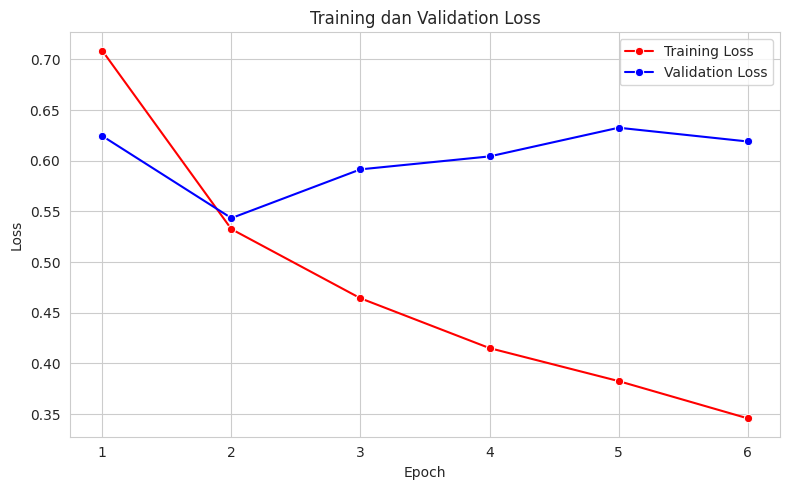

In [ ]:
# Visualisasi training dan Validation loss per epoch
sns.set_style("whitegrid")

log_history = trainer.state.log_history

#Train loss
train_loss_logs = [log for log in log_history if "loss" in log and "eval_loss" not in log]
train_df_raw = pd.DataFrame(train_loss_logs)[["epoch", "loss"]]
train_df_raw["epoch_bin"] = np.ceil(train_df_raw["epoch"])
train_df_loss = train_df_raw.groupby("epoch_bin", as_index=False)["loss"].mean()
train_df_loss = train_df_loss.rename(columns={"epoch_bin": "epoch", "loss": "value"})
train_df_loss["metric"] = "Training Loss"

#Validation loss (test data)
eval_logs = [log for log in log_history if "eval_loss" in log]
eval_df_loss = pd.DataFrame(eval_logs)[["epoch", "eval_loss"]].rename(columns={"eval_loss": "value"})
eval_df_loss["metric"] = "Validation Loss"

loss_df = pd.concat([train_df_loss, eval_df_loss], ignore_index=True)

plt.figure(figsize=(8, 5))
sns.lineplot(data=loss_df, x="epoch", y="value", hue="metric", marker="o",
             palette={"Training Loss": "r", "Validation Loss": "b"})
plt.title("Training dan Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, int(loss_df["epoch"].max()) + 1))
plt.legend(title="")
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()

Grafik diatas menunjukkan training loss yang terus menurun, sedangkan
validation loss mencapai titik terendah pada epoch ke-2 lalu cenderung
meningkat setelahnya. Hal ini mengindikasikan mulai terjadinya overfitting,
sehingga model terbaik dipilih berdasarkan checkpoint dengan validation
loss terendah, bukan epoch terakhir.

#Evaluasi Per Kelas

In [ ]:
#Evaluasi model pada data uji
pred_output = trainer.predict(test_dataset)
y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=1)

target_names = list(label_encoder.classes_)

print("=== Classification Report (per kelas) ===")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
print("=== Confusion Matrix ===")
print(cm)

=== Classification Report (per kelas) ===
              precision    recall  f1-score   support

    negative       0.83      0.86      0.85       409
     neutral       0.78      0.63      0.70       213
    positive       0.61      0.80      0.70        81

    accuracy                           0.79       703
   macro avg       0.74      0.76      0.75       703
weighted avg       0.79      0.79      0.78       703

=== Confusion Matrix ===
[[353  33  23]
 [ 61 134  18]
 [ 11   5  65]]


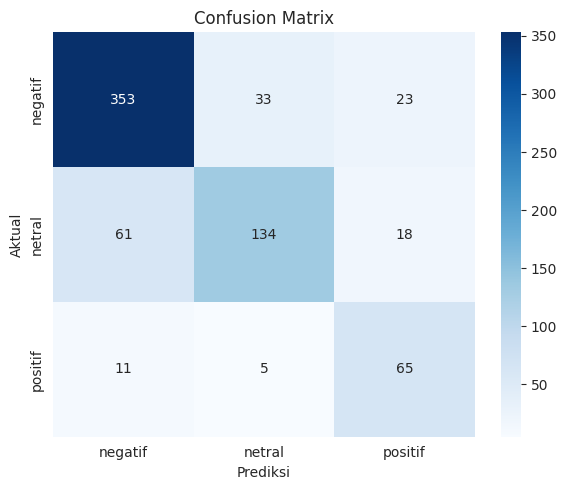

In [ ]:
#Visualisasi confusion matrix
label_id_map = {"negative": "negatif", "neutral": "netral", "positive": "positif"}
target_names_id = [label_id_map.get(t, t) for t in target_names]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names_id, yticklabels=target_names_id)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

Confusion matrix menunjukkan model paling akurat memprediksi kelas negatif
(353 dari 409 data), diikuti kelas positif (65 dari 81 data). Kelas netral
memiliki tingkat kesalahan prediksi paling tinggi (134 dari 213 data benar),
di mana sebagian besar kesalahannya tertukar dengan kelas negatif (61 data)
dibandingkan kelas positif (18 data), yang kemungkinan disebabkan jumlah
data netral yang jauh lebih sedikit dibanding kelas negatif.

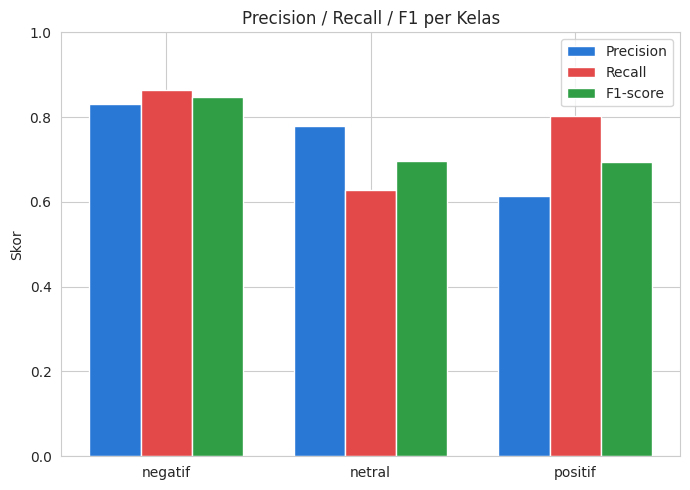

In [ ]:
#Visualisasi precision, recall, dan f1-score per kelas
report_dict = classification_report(y_true, y_pred, target_names=target_names,
                                     zero_division=0, output_dict=True)

metrics_df = pd.DataFrame(report_dict).T.loc[target_names, ["precision", "recall", "f1-score"]]

x = np.arange(len(target_names))
width = 0.25

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width, metrics_df["precision"], width, label="Precision", color="#2a78d6")
ax.bar(x, metrics_df["recall"], width, label="Recall",    color="#e34948")
ax.bar(x + width,  metrics_df["f1-score"],  width, label="F1-score",  color="#2f9e44")

ax.set_xticks(x)
ax.set_xticklabels(label_id_map.get(t, t) for t in target_names)
ax.set_ylim(0, 1)
ax.set_ylabel("Skor")
ax.set_title("Precision / Recall / F1 per Kelas")
ax.legend()
plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=150)
plt.show()

Grafik menunjukkan kelas negatif memperoleh skor precision, recall, dan
F1-score tertinggi di antara ketiga kelas. Kelas positif memiliki recall
yang cukup tinggi namun precision paling rendah, sedangkan kelas netral
memiliki recall paling rendah, yang sejalan dengan hasil confusion matrix
di mana banyak data netral salah diprediksi sebagai kelas negatif.

#Simpan Model

In [ ]:
save_path = "./model_final"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

import pickle
with open(f"{save_path}/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
!zip -r model_final.zip model_final

  adding: model_final/ (stored 0%)
  adding: model_final/tokenizer_config.json (deflated 43%)
  adding: model_final/model.safetensors (deflated 7%)
  adding: model_final/label_encoder.pkl (deflated 18%)
  adding: model_final/tokenizer.json (deflated 71%)
  adding: model_final/config.json (deflated 57%)
  adding: model_final/training_args.bin (deflated 53%)


In [ ]:
# from google.colab import files
# files.download("model_final.zip")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!cp -r model_final /content/drive/MyDrive/

Mounted at /content/drive


In [ ]:
!ls -la model_final/

total 486856
drwxr-xr-x 2 root root      4096 Jul 18 14:56 .
drwxr-xr-x 1 root root      4096 Jul 18 15:01 ..
-rw-r--r-- 1 root root      1260 Jul 18 14:55 config.json
-rw-r--r-- 1 root root       275 Jul 18 14:56 label_encoder.pkl
-rw------- 1 root root 497798148 Jul 18 14:56 model.safetensors
-rw-r--r-- 1 root root       379 Jul 18 14:56 tokenizer_config.json
-rw-r--r-- 1 root root    709292 Jul 18 14:56 tokenizer.json
-rw-r--r-- 1 root root      5201 Jul 18 14:56 training_args.bin


#Test config

In [ ]:
model_test = trainer.model
model_test.eval()
model_test.to(device)

inputs = tokenizer("aplikasi ini bagus banget", return_tensors="pt").to(device)
with torch.no_grad():
    logits = model_test(**inputs).logits
print("Bagus:", torch.softmax(logits, dim=-1))

inputs2 = tokenizer("aplikasi ini jelek banget", return_tensors="pt").to(device)
with torch.no_grad():
    logits2 = model_test(**inputs2).logits
print("Jelek:", torch.softmax(logits2, dim=-1))

Bagus: tensor([[0.0153, 0.0015, 0.9831]], device='cuda:0')
Jelek: tensor([[0.9957, 0.0024, 0.0020]], device='cuda:0')


In [ ]:
kalimat_tes = "mbg mas bahlil gantneg"
inputs = tokenizer(kalimat_tes, return_tensors="pt").to(device)
with torch.no_grad():
    logits = model_test(**inputs).logits
probs = torch.softmax(logits, dim=-1)

print("Kalimat:", kalimat_tes)
print("Probabilitas:", probs)
print("Prediksi kelas:", label_encoder.classes_[torch.argmax(probs).item()])

Kalimat: mbg mas bahlil gantneg
Probabilitas: tensor([[0.3292, 0.5346, 0.1362]], device='cuda:0')
Prediksi kelas: neutral


Prediksi Model seluruh data dan digabuyng dnegan kolom preprocessing

In [ ]:
# Load ulang ipusnasdata.csv (versi lengkap,semua tahap preprocessing)
df_full = pd.read_csv(
    "https://raw.githubusercontent.com/ariesdav/scrape-playstore/refs/heads/main/data/ipusnasdata.csv"
)
df_full["final_text"] = df_full["final_text"].fillna("")



In [ ]:
model_test.eval()
all_texts = df_full["final_text"].tolist()

all_preds, all_confidences = [], []
batch_size = 32

with torch.no_grad():
    for i in range(0, len(all_texts), batch_size):
        batch = all_texts[i:i + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", truncation=True,
                            padding=True, max_length=MAX_LEN).to(device)
        logits = model_test(**inputs).logits
        probs = torch.softmax(logits, dim=-1)
        conf, pred = torch.max(probs, dim=-1)
        all_preds.extend(pred.cpu().tolist())
        all_confidences.extend(conf.cpu().tolist())

In [ ]:
# Kolom sentimentLabel di-OVERWRITE dengan hasil prediksi model
# (bukan ground truth training), karena confidence cuma valid dipasangkan
# dengan label yang benar-benar dipilih model.
df_full["sentimentLabel"] = label_encoder.inverse_transform(all_preds)
df_full["confidence"] = all_confidences

In [ ]:
# Simpan SEMUA kolom (content s.d. final_text + sentimentLabel + confidence)
# supaya file ini langsung bisa dipreview di tiap tahap preprocessing DAN
# langsung punya hasil klasifikasi + confidence -> siap dipakai sbg
# "Data Contoh (Sudah Dianalisis)" di Streamlit, tanpa upload / re-run apapun.
output_cols = [
    "content", "case_folding", "cleaning", "slang",
    "tokenizing", "filtered", "stemmed", "final_text",
    "sentimentLabel", "confidence",
]
df_final = df_full[output_cols]
df_final.to_csv("ipusnasdata_analyzed.csv", index=False)

In [ ]:
df_final["sentimentLabel"].value_counts()
df_final.head()

,content,case_folding,cleaning,slang,tokenizing,filtered,stemmed,final_text,sentimentLabel,confidence
0,"sebagai warga yang dengan dana minim, tapi ing...","sebagai warga yang dengan dana minim, tapi ing...",sebagai warga yang dengan dana minim tapi ingi...,sebagai warga yang dengan dana minim tapi ingi...,"['sebagai', 'warga', 'yang', 'dengan', 'dana',...","['warga', 'dana', 'minim', 'membaca', 'mohon',...","['warga', 'dana', 'minim', 'baca', 'mohon', 't...",warga dana minim baca mohon tingkat aplikasi j...,negative,0.978778
1,hp saya android 9 mendadak sudah tidak bisa di...,hp saya android 9 mendadak sudah tidak bisa di...,hp saya android mendadak sudah tidak bisa digu...,hp saya android mendadak sudah tidak bisa digu...,"['hp', 'saya', 'android', 'mendadak', 'sudah',...","['hp', 'android', 'mendadak', 'tidak', 'mengak...","['hp', 'android', 'dadak', 'tidak', 'akses', '...",hp android dadak tidak akses ipusnas digilib s...,negative,0.993349
2,update terbaru 9 mei 2026 alangkah susahnya ya...,update terbaru 9 mei 2026 alangkah susahnya ya...,update terbaru mei alangkah susahnya ya mau ba...,update terbaru mei alangkah susahnya ya mau ba...,"['update', 'terbaru', 'mei', 'alangkah', 'susa...","['update', 'terbaru', 'mei', 'alangkah', 'susa...","['update', 'baru', 'mei', 'alangkah', 'susah',...",update baru mei alangkah susah ya baca buku ve...,negative,0.983179
3,Cant even log in,cant even log in,cant even log in,cant even log ini,"['cant', 'even', 'log', 'ini']","['cant', 'even', 'log']","['cant', 'even', 'log']",cant even log,negative,0.983855
4,aplikasinya makin lama makin jelek aja. dari y...,aplikasinya makin lama makin jelek aja. dari y...,aplikasinya makin lama makin jelek aja dari yg...,aplikasinya makin lama makin jelek saja dari y...,"['aplikasinya', 'makin', 'lama', 'makin', 'jel...","['aplikasinya', 'jelek', 'awalny', 'ngelag', '...","['aplikasi', 'jelek', 'awalny', 'ngelag', 'ero...",aplikasi jelek awalny ngelag eror enggak minje...,negative,0.988801


In [ ]:
from google.colab import files
files.download("finalipusnasdata.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>